# EDA inicial - Cancelación de reservas

Este notebook analiza nulos, distribución de clases y variables clave para justificar el enfoque de modelado.

## Justificación de métricas

Se usa **AUC-ROC** como métrica principal porque el problema puede estar desbalanceado y AUC-ROC evalúa la capacidad discriminativa del modelo para todos los umbrales.

Además se reportan **accuracy, precision, recall y F1-score** para analizar costes de falsos positivos y falsos negativos.

## 1. Carga e inspección

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import missingno as msno
import seaborn as sns

import folium
from folium.plugins import HeatMap
import plotly.express as px


In [3]:
df = pd.read_csv('../../data/raw/dataset_practica_final.csv')

In [4]:
# Resumen estadístico de las columnas numéricas
df.head()
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Mostrar las dimensiones del DataFrame
df.shape

(119390, 32)

In [6]:

# Tipos de datos de cada columna
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [7]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 2. Variable objetivo

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


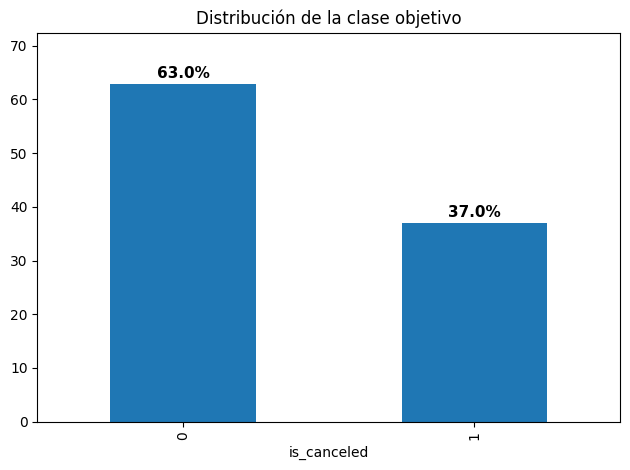

In [8]:
# Selección de la variable objetivo
target = df['is_canceled']

# Distribución de la clase objetivo 
print(target.value_counts())

# Distribución de la clase objetivo en porcentaje
print(target.value_counts(normalize=True) * 100)

# Visualización en porcentaje de la distribución de la clase objetivo
pcts = target.value_counts(normalize=True) * 100
ax = pcts.plot(kind='bar', title='Distribución de la clase objetivo')

for bar, pct in zip(ax.patches, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.ylim(0, pcts.max() * 1.15)
plt.tight_layout()
plt.show()


## 3. Valores nulos y duplicados

In [9]:
# Cuantos nulos hay en cada columna
nulos = df.isnull().sum()
pct_nulos = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% sobre total': pct_nulos.round(3)})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Nulos por columna:")
print(resumen_nulos.to_string())

# Separador
print("=" * 50)

# Filas duplicadas
dup = df.duplicated().sum()
print(f"Filas duplicadas: {dup} ({dup / len(df) * 100:.2f}%)")


Nulos por columna:
           Nulos  % sobre total
company   112593         94.307
agent      16340         13.686
country      488          0.409
children       4          0.003
Filas duplicadas: 31994 (26.80%)


## 3.1 Tratamiento de valores nulos

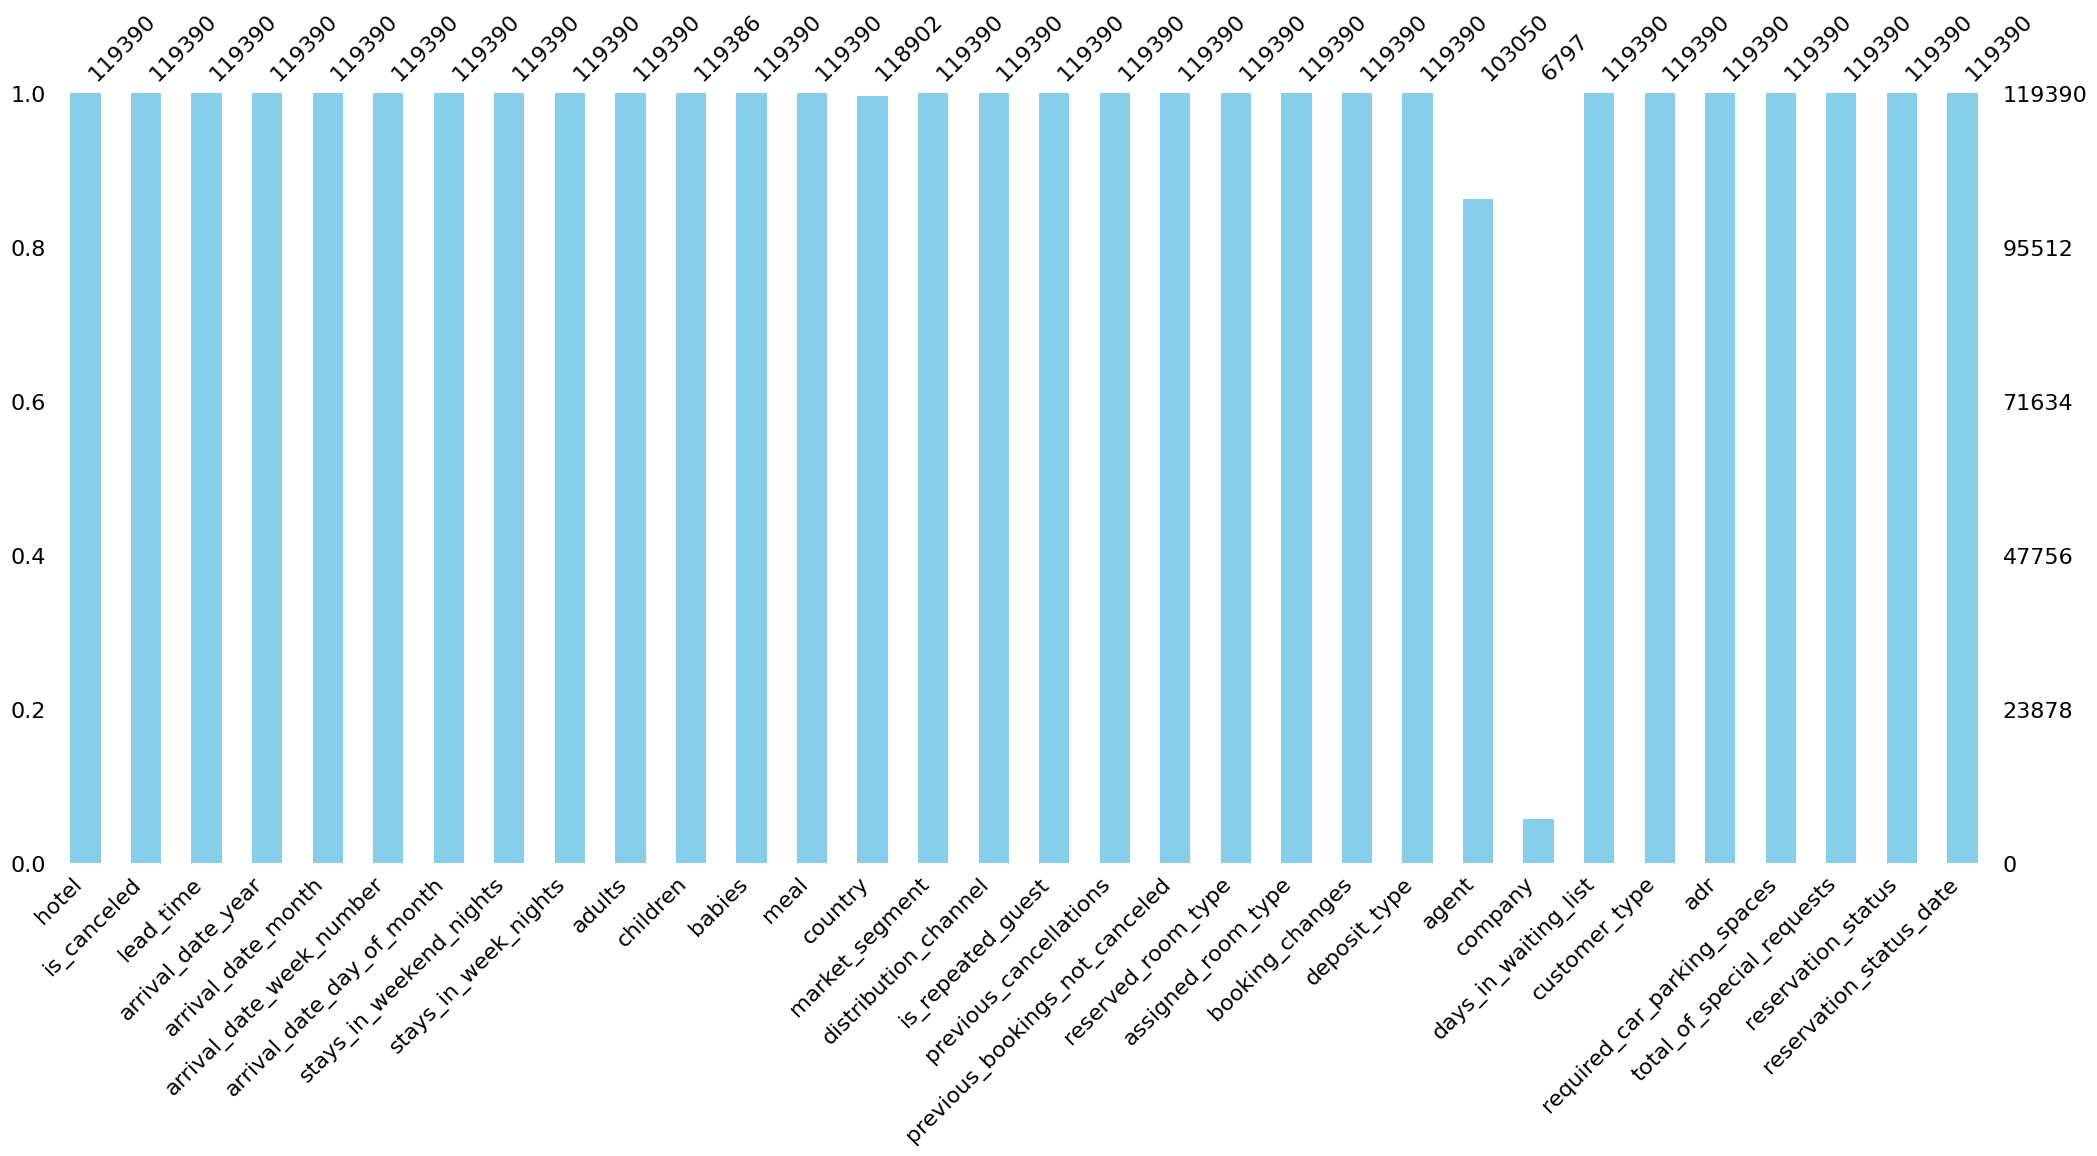

In [10]:
# Previsualizacion de valores nulos
msno.bar(df, color='skyblue')
plt.show()

In [11]:
# Filas con 0 huéspedes (children, adults, babies) 
# No tiene sentido que haya reservas sin huéspedes, por lo que estas filas probablemente sean errores de entrada de datos. Es importante identificarlas y eliminarlas para evitar que afecten el análisis y los modelos predictivos.
filter = (df.children == 0) & (df.adults == 0) & (df.babies == 0)
df[filter]
# contamos cuántas filas cumplen esta condición
print(f"Filas con 0 huéspedes: {filter.sum()}")


Filas con 0 huéspedes: 180


In [12]:
# Estas filas no tienen sentido, ya que no hay huéspedes. Probablemente sean errores de entrada de datos, por lo que las eliminamos
# ~filter es lo mismo que filter == False, es decir, quedarnos solo con las filas que no cumplen esa condición
df_clean = df[~filter]
df_clean

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


## 3.2 Pais de origen de los huéspedes

In [14]:
# De que pais vienen los huéspedes que no cancelaron su reserva?
country_good_client = df_clean[df_clean['is_canceled'] == 0]['country'].value_counts().reset_index()
# Renombramos las columnas para que sean más descriptivas y visualizamos porcentajes por cada pais
country_good_client.columns = ['country', 'No of guests']
country_good_client

# Lo mejores clientes son de portugal 

,country,No of guests
0,PRT,20977
1,GBR,9668
2,FRA,8468
3,ESP,6383
4,DEU,6067
...,...,...
160,SDN,1
161,ATF,1
162,TJK,1
163,SLE,1


In [161]:
basemap = folium.Map()
guests_map = px.choropleth(
    country_good_client,
    locations='country',
    color='No of guests',
    hover_name='country',
    labels={'No of guests': 'Número de clientes', 'country': 'País'}
)
guests_map.show()

In [162]:

# children: 4 nulos: imputar con 0
df_clean['children'] = df_clean['children'].fillna(0)

# country: 488 nulos: imputar con 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Para evitar la alta cardinalidad en la columna "country", 
# se agrupan los países menos frecuentes en una categoría "Other". 
# Se identifican los 10 países más comunes y se reemplazan los 
# demás con "Other". Esto ayuda a reducir la cantidad de categorías 
# únicas y mejora la capacidad del modelo para generalizar.
top_countries = df_clean["country"].value_counts().nlargest(10).index
df_clean["country"] = df_clean["country"].where(
    df_clean["country"].isin(top_countries),
    "Other",
)

# agent: 16.340 nulos: el nulo significa "sin agente" (reserva directa)
# Se convierte en variable binaria más informativa que el ID numérico
df_clean['has_agent'] = df_clean['agent'].notnull().astype(int)
df_clean = df_clean.drop(columns=['agent'])

# company: 94.3% nulos: eliminar directamente
df_clean = df_clean.drop(columns=['company'])

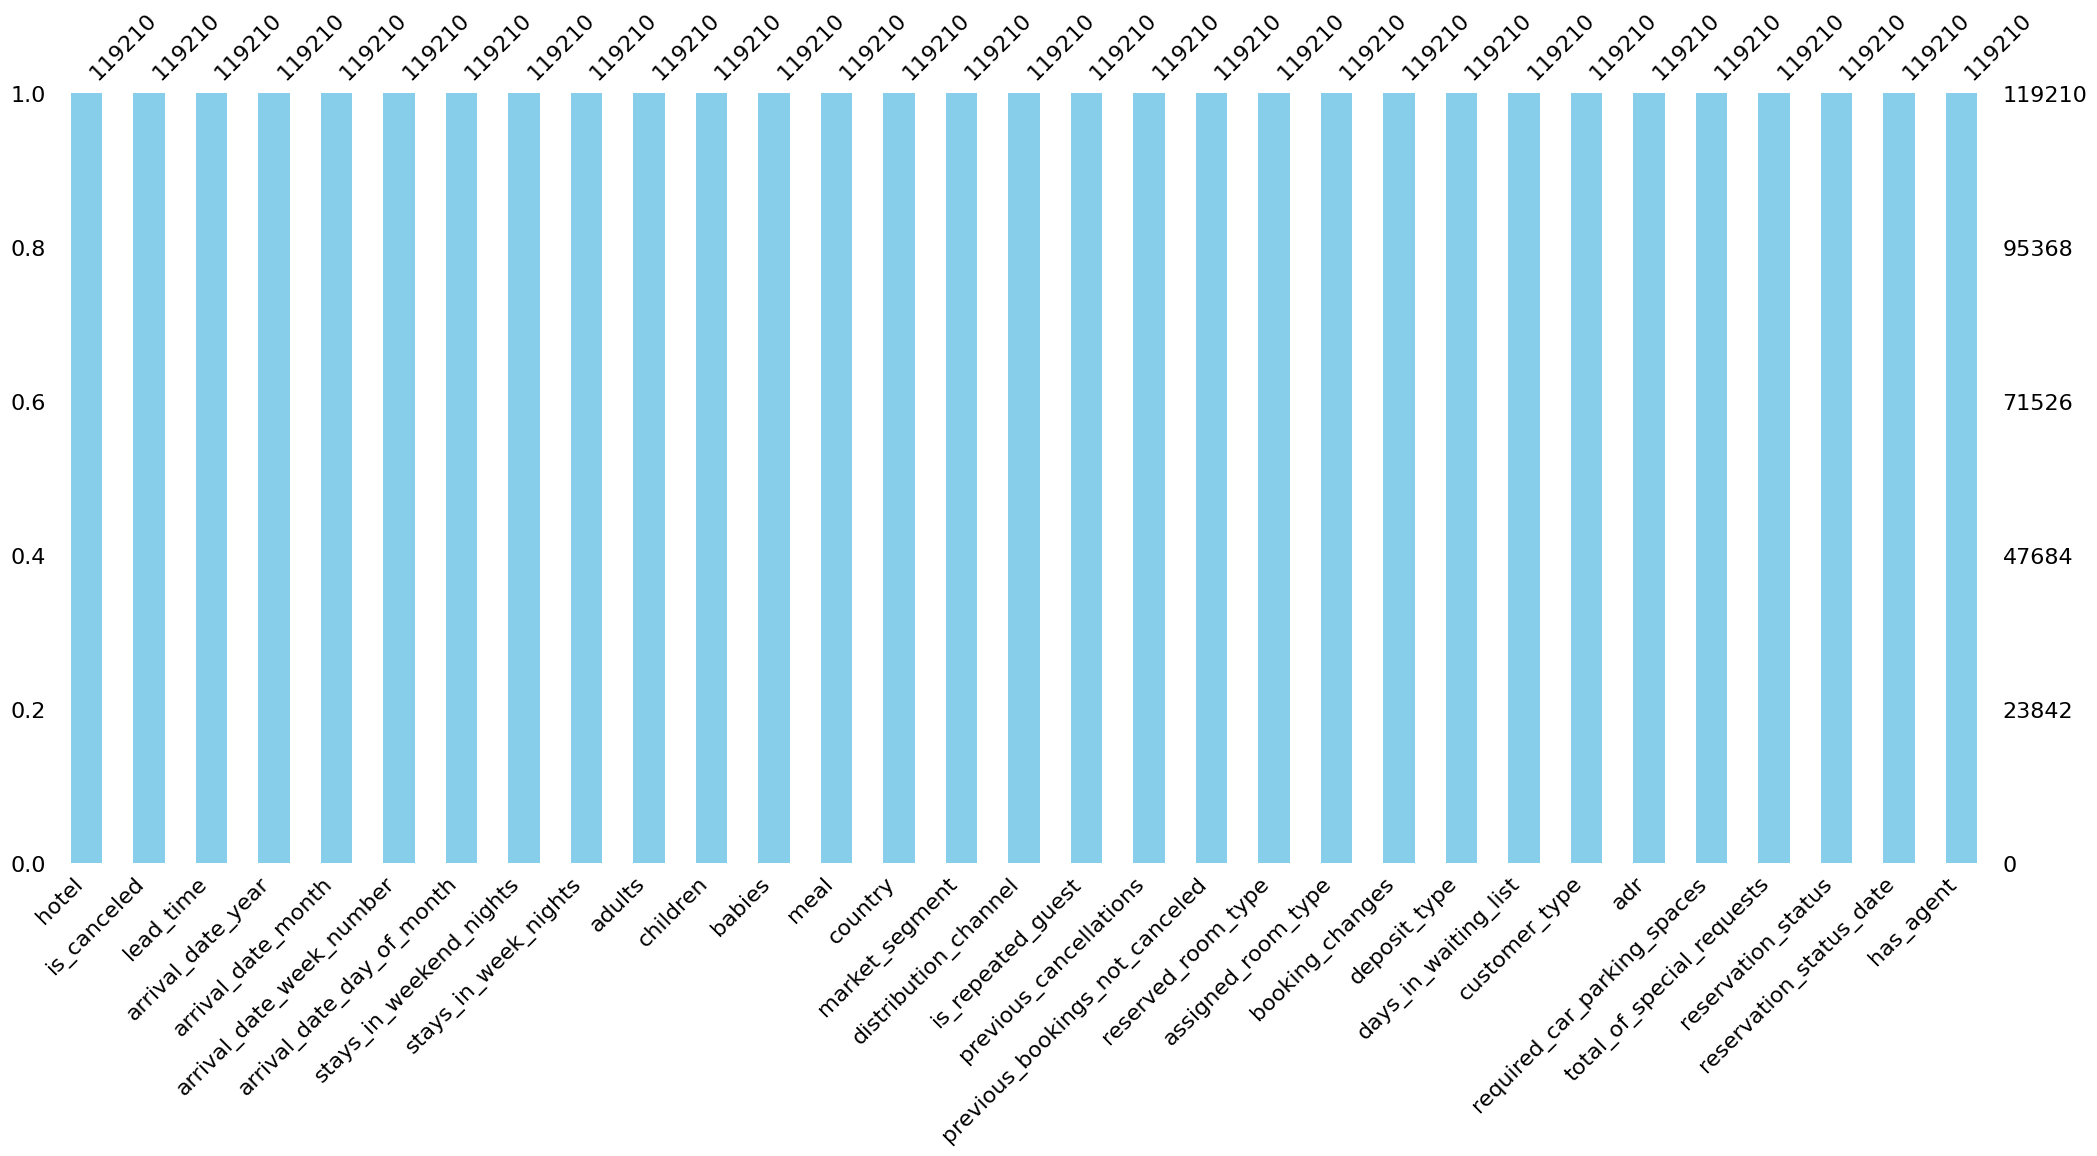

In [163]:
# La altura de cada barra indica cuántos datos no nulos hay en esa columna.
msno.bar(df_clean, color='skyblue')
plt.show()

In [164]:
# Resumen estadístico de las columnas numéricas

data = df[df['is_canceled'] == 0]
# Boxplot de ADR por tipo de habitación reservada, separado por tipo de hotel
# Lo usamos para ver si hay diferencias en el ADR (Average Daily Rate) entre los tipos de habitación reservada
# y entre los tipos de hotel (City Hotel vs Resort Hotel). Esto puede ayudar a identificar patrones en el comportamiento de los clientes que no cancelaron su reserva.
# la columna x es el tipo de habitación reservada (reserved_room_type), la columna de y es el ADR (Average Daily Rate) y el color representa el tipo de hotel (hotel). El template 'plotly_dark' se utiliza para mejorar la apariencia del gráfico.
# Podemos ver la agrupacion de los datos, la mediana, los cuartiles y los posibles valores atípicos (outliers) en el ADR para cada tipo de habitación y tipo de hotel. Esto puede proporcionar información sobre las preferencias de los clientes y las diferencias en los precios entre los tipos de habitaciones y hoteles.
px.box(data_frame = data, x = 'reserved_room_type', y = 'adr', color = 'hotel', template = 'plotly_dark')


In [165]:
# Obtenermos el número de habitaciones que no se han cancelado por tipo de habitación reservada
data_by_type = df[df['is_canceled'] == 0]
px.histogram(data_frame = data_by_type, x = 'reserved_room_type', color = 'hotel', template = 'plotly_dark')


## Analisis de variedad del precio por noche a lo largo del año

In [166]:
# Asignamos a dos variables los datos de los hoteles que no se han cancelado para cada tipo de hotel
hotel_resort = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]
hotel_city = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)]

In [167]:
# Agregamos el analisis de variedad para el Resort Hotel, agrupando por mes de llegada y calculando el precio promedio (ADR) para cada mes.
# Esto nos permitirá comparar cómo varía el precio a lo largo del año entre los dos tipos de hoteles.
resort_hotel = hotel_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()
resort_hotel

,arrival_date_month,adr
0,April,75.867816
1,August,181.205892
2,December,68.322236
3,February,54.147478
4,January,48.708919
5,July,150.122528
6,June,107.921869
7,March,57.012487
8,May,76.657558
9,November,48.681640


In [168]:
# Agregamos el análisis de la variedad del precio por noche a lo largo del año para el City Hotel, agrupando por mes de llegada y calculando el precio promedio (ADR) para cada mes. 
city_hotel = hotel_city.groupby(['arrival_date_month'])['adr'].mean().reset_index()
city_hotel

,arrival_date_month,adr
0,April,111.856824
1,August,118.412083
2,December,87.856764
3,February,86.183025
4,January,82.160634
5,July,115.563810
6,June,117.702075
7,March,90.170722
8,May,120.445842
9,November,86.500456


In [169]:
final_hotel = resort_hotel.merge(city_hotel, on = 'arrival_date_month')
final_hotel.columns = ['month', 'price_for_resort', 'price_for_city_hotel']
final_hotel

,month,price_for_resort,price_for_city_hotel
0,April,75.867816,111.856824
1,August,181.205892,118.412083
2,December,68.322236,87.856764
3,February,54.147478,86.183025
4,January,48.708919,82.160634
5,July,150.122528,115.563810
6,June,107.921869,117.702075
7,March,57.012487,90.170722
8,May,76.657558,120.445842
9,November,48.681640,86.500456


In [170]:
import sort_dataframeby_monthorweek as sd

def sort_month(df, column_name):
    return sd.Sort_Dataframeby_Month(df, column_name)

In [171]:
final_prices = sort_month(final_hotel, 'month')
final_prices

,month,price_for_resort,price_for_city_hotel
0,January,48.708919,82.160634
1,February,54.147478,86.183025
2,March,57.012487,90.170722
3,April,75.867816,111.856824
4,May,76.657558,120.445842
5,June,107.921869,117.702075
6,July,150.122528,115.563810
7,August,181.205892,118.412083
8,September,96.416860,112.598452
9,October,61.727505,101.745956


In [172]:
plt.figure(figsize = (17, 8))

px.line(final_prices, x = 'month', y = ['price_for_resort','price_for_city_hotel'],
        title = 'Room price per night over the Months', template = 'plotly_dark')

# Vemos que en agosto el precio de los resort hotel es más alto que el del city hotel,
# lo que podría indicar una mayor demanda en ese mes para el resort hotel.
# El precio del City hotel es mas alto en los meses de invierno, lo que podría indicar una mayor demanda en esos meses para el city hotel.
# Esto podría deberse a que los clientes prefieren alojarse en un hotel de ciudad durante los meses más fríos, mientras que los hoteles resort pueden ser más populares durante los meses de verano.


<Figure size 1700x800 with 0 Axes>

###  Visualizamos los meses que mas clientes tienen

In [173]:
resort_guests = hotel_resort['arrival_date_month'].value_counts().reset_index()
resort_guests.columns=['month','no of guests']
# Ordenamos los meses para que se muestren en el orden correcto
resort_guests = sort_month(resort_guests, 'month')
resort_guests

,month,no of guests
0,January,1868
1,February,2308
2,March,2573
3,April,2550
4,May,2535
5,June,2038
6,July,3137
7,August,3257
8,September,2102
9,October,2577


In [174]:
city_guests = hotel_city['arrival_date_month'].value_counts().reset_index()
city_guests.columns=['month','no of guests']
city_guests = sort_month(city_guests, 'month')
city_guests

,month,no of guests
0,January,2254
1,February,3064
2,March,4072
3,April,4015
4,May,4579
5,June,4366
6,July,4782
7,August,5381
8,September,4290
9,October,4337


In [175]:
final_guests = resort_guests.merge(city_guests,on='month')
final_guests.columns=['month','no of guests in resort','no of guest in city hotel']
final_guests

,month,no of guests in resort,no of guest in city hotel
0,January,1868,2254
1,February,2308,3064
2,March,2573,4072
3,April,2550,4015
4,May,2535,4579
5,June,2038,4366
6,July,3137,4782
7,August,3257,5381
8,September,2102,4290
9,October,2577,4337


In [176]:
px.line(final_guests, x = 'month', y = ['no of guests in resort','no of guest in city hotel'],
        title='Total no of guests per Months', template = 'plotly_dark')

### Cuanto tiempo estan los clientes en los hoteles

In [177]:
filter = df['is_canceled'] == 0
data = df[filter]
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [178]:
data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2


In [179]:
stay = data.groupby(['total_nights', 'hotel']).agg('count').reset_index()
stay = stay.iloc[:, :3]
stay = stay.rename(columns={'is_canceled':'Number of stays'})
stay

,total_nights,hotel,Number of stays
0,0,City Hotel,308
1,0,Resort Hotel,372
2,1,City Hotel,9169
3,1,Resort Hotel,6580
4,2,City Hotel,10992
...,...,...,...
63,49,City Hotel,1
64,56,Resort Hotel,1
65,57,City Hotel,1
66,60,Resort Hotel,1


In [180]:
px.bar(data_frame = stay, x = 'total_nights', y = 'Number of stays', color = 'hotel', barmode = 'group',
        template = 'plotly_dark')

## 3.2 Tratamiento de duplicados

In [15]:
n_before = len(df_clean)
dup_mask = df_clean.duplicated(keep=False)
filas_duplicadas = df_clean[dup_mask]

df_clean = df_clean.drop_duplicates()
n_after = len(df_clean)
print(f"Filas antes:           {n_before:,}")
print(f"Filas después:         {n_after:,}")

Filas antes:           119,210
Filas después:         87,230


## 3.3 Variables con data leakage

`reservation_status` y `reservation_status_date` revelan directamente el resultado que queremos predecir:

Incluirlas en el modelo sería hacer trampa: aprendería la etiqueta en lugar de los patrones de comportamiento del cliente. Las eliminamos de hacer cualquier análisis.

In [182]:
leakage_cols = ['reservation_status', 'reservation_status_date']
df_clean = df_clean.drop(columns=leakage_cols)

## 4. Estadísticas descriptivas

In [183]:
# Resumen estadístico de las columnas numéricas
df_clean.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,86978.0,0.275989,0.447014,0.00,0.00,0.00,1.0,1.0
lead_time,86978.0,79.878199,85.970979,0.00,11.00,49.00,125.0,737.0
arrival_date_year,86978.0,2016.210766,0.685943,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,86978.0,26.827715,13.664966,1.00,16.00,27.00,37.0,53.0
arrival_date_day_of_month,86978.0,15.811631,8.838316,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,86978.0,1.005312,1.028032,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,86978.0,2.625354,2.041781,0.00,1.00,2.00,4.0,50.0
adults,86978.0,1.880866,0.621422,0.00,2.00,2.00,2.0,55.0
children,86978.0,0.139288,0.456855,0.00,0.00,0.00,0.0,10.0
babies,86978.0,0.010853,0.113768,0.00,0.00,0.00,0.0,10.0


Podemos observar que el mínimo de ``adr`` es negativo. Al tratarse de un campo que muestra el precio noche es algo imposible y seguramente se trate de un error al introducir los datos, para asegurarnos de que no influya en el entrenamiento nos encargamos de eliminarlo

In [184]:
df_clean = df_clean[df_clean['adr'] >= 0]

In [185]:
# Comprbamos que no hay valores negativos en 'adr'
print(f"Valores negativos en 'adr': {(df_clean['adr'] < 0).sum()}")

# Comproamos las estadísticas de 'adr' para detectar posibles outliers
df_clean['adr'].describe().transpose()

Valores negativos en 'adr': 0


count    86977.000000
mean       106.550924
std         54.943151
min          0.000000
25%         72.250000
50%         98.250000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

In [186]:
# Resumen estadístico de las columnas categóricas
df_clean.describe(include='object').transpose()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6724\84489620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include='object').transpose()


,count,unique,top,freq
hotel,86977,2,City Hotel,53043
arrival_date_month,86977,12,August,11232
meal,86977,5,BB,67678
country,86977,11,PRT,27344
market_segment,86977,8,Online TA,51510
distribution_channel,86977,5,TA/TO,68852
reserved_room_type,86977,9,A,56197
assigned_room_type,86977,11,A,46079
deposit_type,86977,3,No Deposit,85832
customer_type,86977,4,Transient,71786


## 5. Distribuciones de variables numéricas

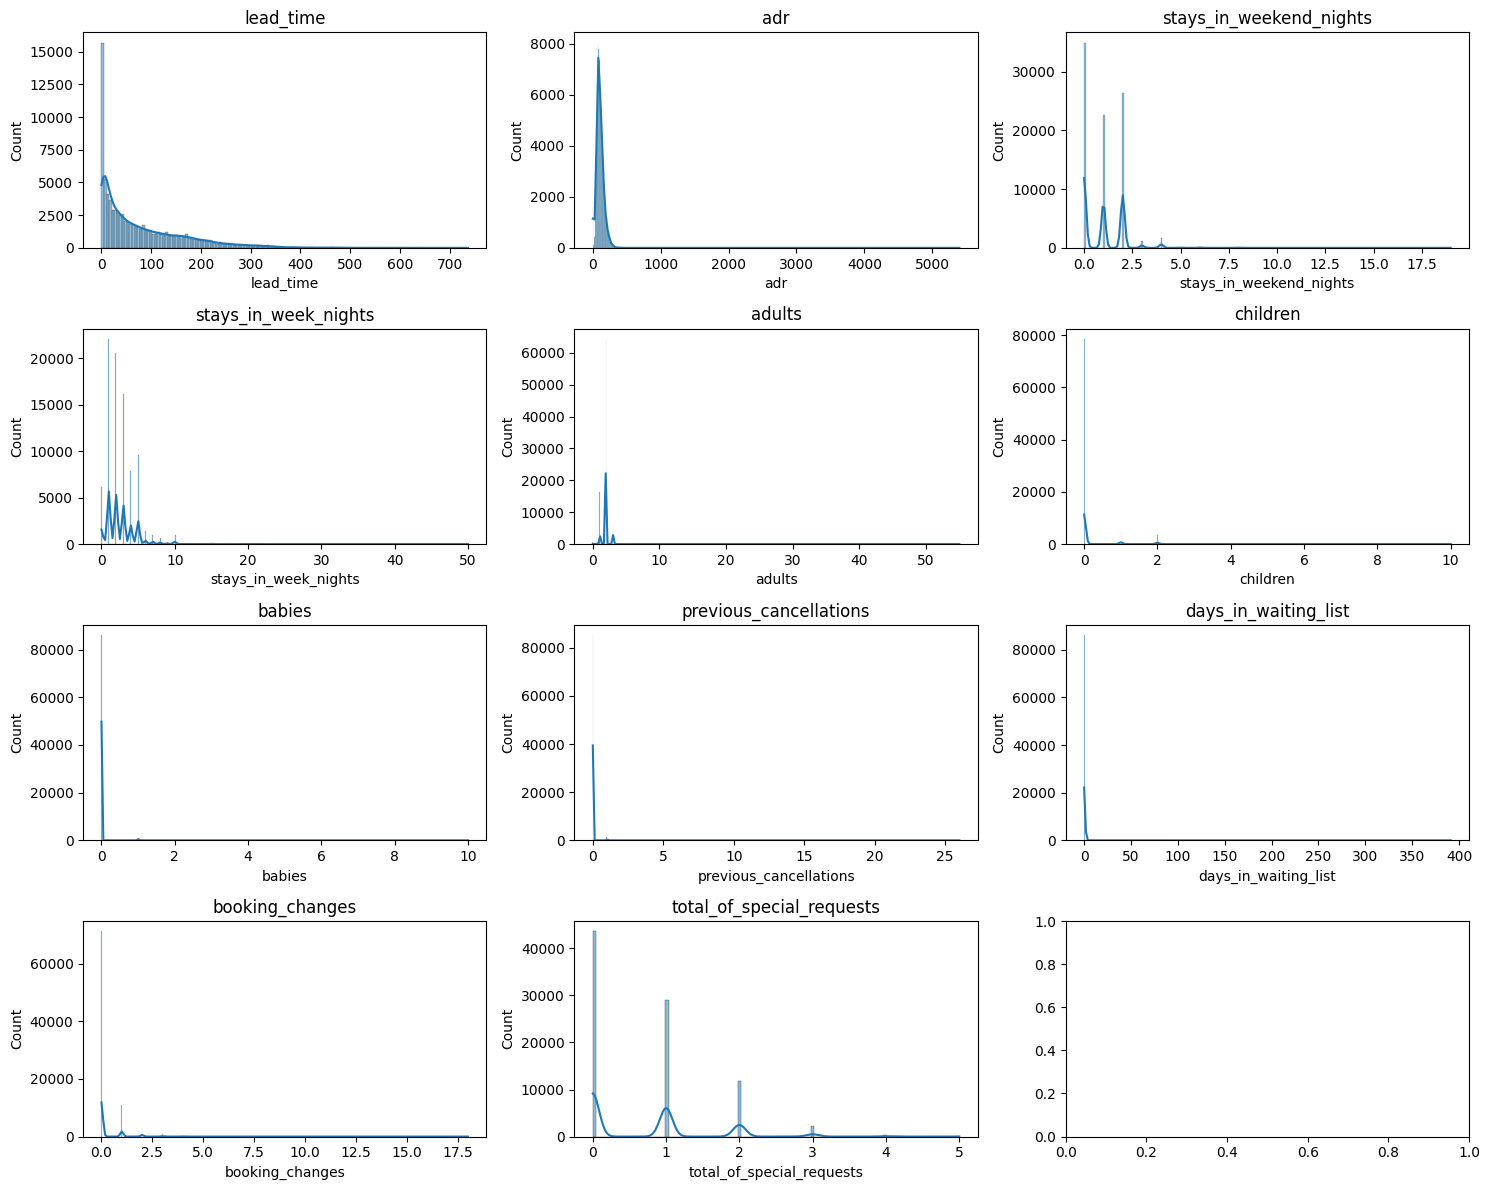

In [187]:
# Visualización de la distribución de las variables numéricas
cols_to_plot = [
    'lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'days_in_waiting_list', 'booking_changes', 'total_of_special_requests'
]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df_clean[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 6. Variables categóricas

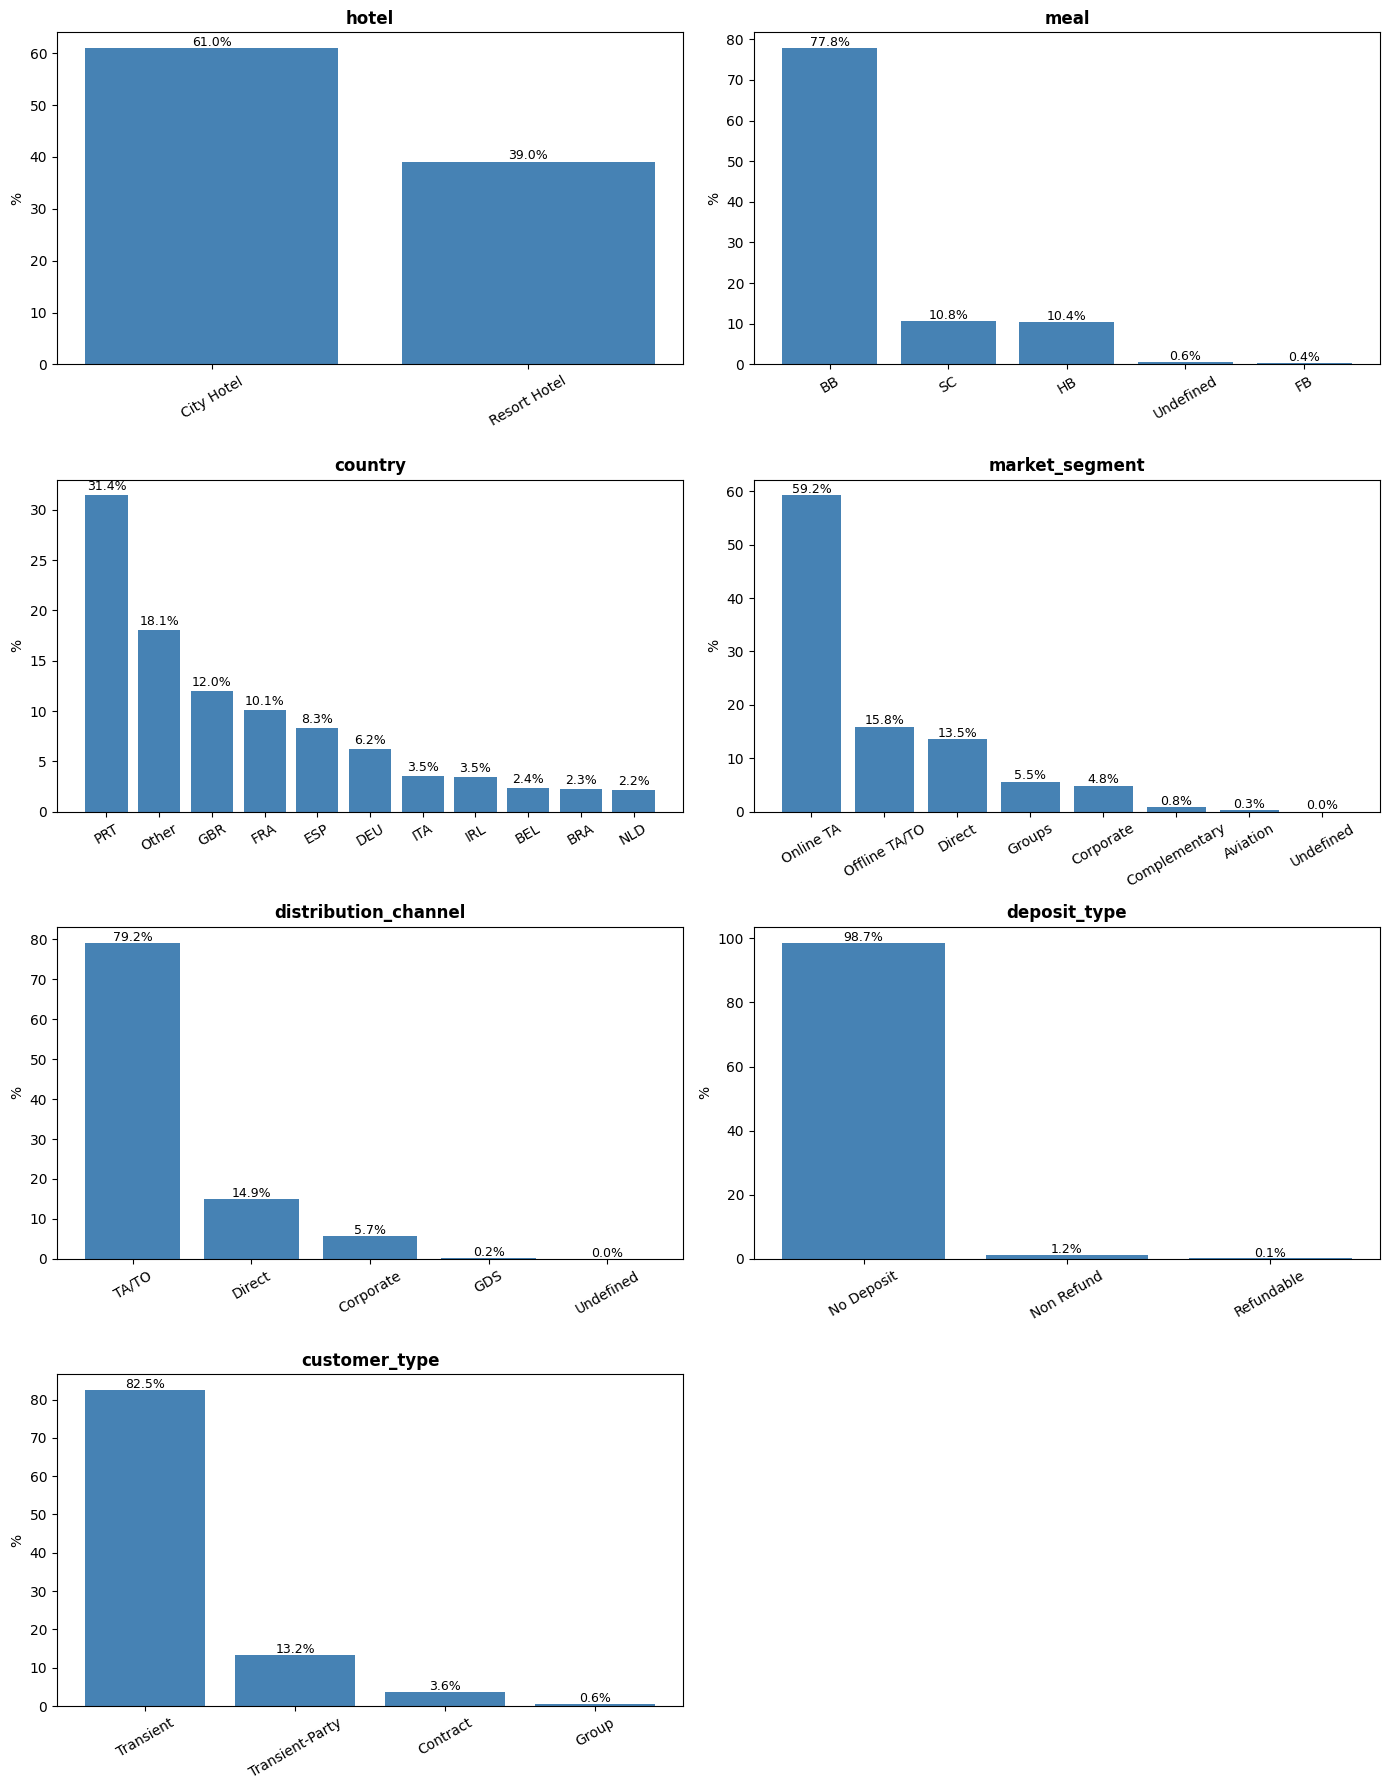

In [188]:
cat_vars = ['hotel', 'meal', 'country', 'market_segment',
            'distribution_channel', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    counts = df_clean[col].value_counts()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, pcts.values, color='steelblue')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Correlaciones

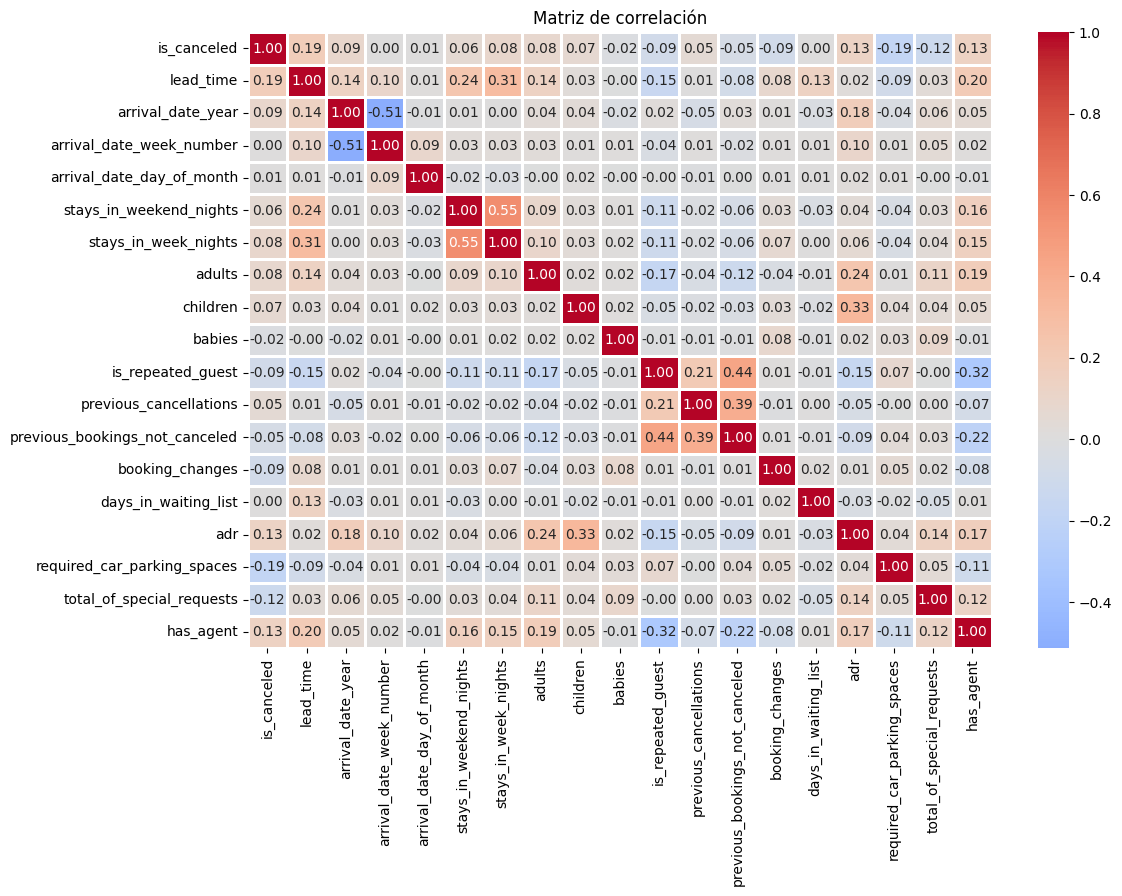

In [106]:
# Matriz de correlación para variables numéricas
corr_matrix = df_clean.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths = 1)
plt.title('Matriz de correlación')
plt.show()


In [ ]:
# Calculamos la correlación absoluta de cada variable numérica con la variable objetivo 'is_canceled'
# y ordenamos los resultados de mayor a menor
# para identificar cuáles variables tienen una relación más fuerte con la cancelación de reservas.
correlation = corr_matrix['is_canceled'].abs().sort_values(ascending=False)
correlation

is_canceled                       1.000000
lead_time                         0.185739
required_car_parking_spaces       0.185098
has_agent                         0.132765
adr                               0.127040
total_of_special_requests         0.121788
booking_changes                   0.093163
is_repeated_guest                 0.089137
arrival_date_year                 0.087921
stays_in_week_nights              0.083838
adults                            0.078964
children                          0.066734
stays_in_weekend_nights           0.060757
previous_bookings_not_canceled    0.052382
previous_cancellations            0.051393
babies                            0.021147
arrival_date_day_of_month         0.005718
days_in_waiting_list              0.004976
arrival_date_week_number          0.001959
Name: is_canceled, dtype: float64